# Multi-Terrain Evaluation Analysis

This notebook loads all CSV evaluation files for a selected approach from an experiment folder, computes metrics per terrain, and computes pooled metrics across all terrains.

Expected filename pattern:

```text
{approach}_{terrain}_{disturbance_condition}.csv
```

Example:

```text
pact_rough_payload.csv
pos_stairs_push.csv
tau_plane_none.csv
```

Set `EXP_FOLDER`, `APPROACH`, and optionally `DISTURBANCE_CONDITION` in the configuration cell below.


In [1]:
import os
import re
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

try:
    import seaborn as sns
except ImportError:
    sns = None


## Configuration

In [2]:
# --- User settings ---
EXP_FOLDER = "exp_data_corl_04/"
APPROACH = "go1_abl2"

# Set to None to load every disturbance condition for this approach.
# Otherwise use strings like "none", "payload", "push", etc.
DISTURBANCE_CONDITION = None

# Optional output directory for result tables
RESULTS_DIR = Path(EXP_FOLDER) / "analysis_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Default target used for height tracking.
BASE_HEIGHT_TARGET = 0.30

# Optional constants used only for limit violation metrics.
# Expected shapes:
#   JOINT_LIMITS: [2, num_dofs], where row 0 is lower and row 1 is upper
#   JOINT_TORQUE_LIMITS: scalar or [num_dofs]
JOINT_LIMITS = np.array([[-1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721],
                         [1.047, 2.966, -0.837, 1.047, 2.966, -0.837, 1.047, 2.966, -0.837, 1.047, 2.966, -0.837]])
JOINT_TORQUE_LIMITS = np.array([23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55])

EPS = 1e-8

EXCLUDE_DIRS = ["analysis_results"]

NUM_WORKERS = 20

## Loading utilities

In [3]:
def string_to_array(array_string):
    """Convert stringified list/array columns from the logger into Python lists."""
    if isinstance(array_string, str):
        try:
            return ast.literal_eval(array_string)
        except (ValueError, SyntaxError):
            return array_string
    return array_string


ARRAY_COLUMNS = [
    "base_cmd",
    "base_pose",
    "base_rpy",
    "dof_pose",
    "base_lin_vel",
    "base_ang_vel",
    "dof_vel",
    "proj_grav",
    "feet_pos",
    "tau_act",
    "grf",
    "q_des",
    "tau_ff",
    "tau_pd",
    "payload",
    "com_shift",
    "rand_push",
    "rand_wrench",
]


def get_csv_converters(columns=ARRAY_COLUMNS):
    return {col: string_to_array for col in columns}


def parse_eval_filename(path, approach):
    """
    Parse filenames of the form:
        {approach}_{terrain}_{disturbance_condition}.csv

    This assumes the terrain token comes immediately after the approach token.
    Everything after the terrain token is treated as the disturbance condition.
    """
    stem = Path(path).stem

    prefix = f"{approach}_"
    if not stem.startswith(prefix):
        return None

    remainder = stem[len(prefix):]
    parts = remainder.split("_")

    if len(parts) < 2:
        return None

    terrain = parts[0]
    disturbance_condition = "_".join(parts[1:])

    return {
        "approach": approach,
        "terrain": terrain,
        "disturbance_condition": disturbance_condition,
        "path": Path(path),
    }


def find_eval_files(exp_folder, approach, disturbance_condition=None):
    exp_folder = Path(exp_folder)

    records = []
    for path in sorted(exp_folder.rglob(f"{approach}_*.csv")):
        info = parse_eval_filename(path, approach)
        if info is None:
            continue

        # Skip blacklisted subdirectories
        if EXCLUDE_DIRS:
            rel_parts = path.relative_to(exp_folder).parts
            if any(part in EXCLUDE_DIRS for part in rel_parts):
                continue

        if disturbance_condition is not None:
            if info["disturbance_condition"] != disturbance_condition:
                continue

        records.append(info)

    return pd.DataFrame(records)


def load_eval_csv(path):
    """Load one evaluation CSV with logger array columns converted."""
    return pd.read_csv(path, converters=get_csv_converters())


def load_eval_dataset(file_table):
    """
    Load all files in file_table and concatenate them into one dataframe.

    Adds:
        approach
        terrain
        disturbance_condition
        source_file
    """
    dfs = []

    for _, row in file_table.iterrows():
        df = load_eval_csv(row["path"])

        df["approach"] = row["approach"]
        df["terrain"] = row["terrain"]
        df["disturbance_condition"] = row["disturbance_condition"]
        df["source_file"] = str(row["path"])

        dfs.append(df)

    if not dfs:
        raise FileNotFoundError("No matching evaluation CSV files were found.")

    return pd.concat(dfs, ignore_index=True)


def _load_one_eval_file(row):
    df = load_eval_csv(row["path"])

    df["approach"] = row["approach"]
    df["terrain"] = row["terrain"]
    df["disturbance_condition"] = row["disturbance_condition"]
    df["source_file"] = str(row["path"])

    return df

def load_eval_dataset_parallel(file_table, max_workers=10):
    rows = [row for _, row in file_table.iterrows()]

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        dfs = list(executor.map(_load_one_eval_file, rows))

    if not dfs:
        raise FileNotFoundError("No matching evaluation CSV files were found.")

    return pd.concat(dfs, ignore_index=True)

In [4]:
file_table = find_eval_files(
    EXP_FOLDER,
    APPROACH,
    disturbance_condition=DISTURBANCE_CONDITION,
)

file_table


,approach,terrain,disturbance_condition,path
0,go1_abl2,discrete,none,exp_data_corl_04/no_disturbance/go1_abl2_discr...
1,go1_abl2,plane,none,exp_data_corl_04/no_disturbance/go1_abl2_plane...
2,go1_abl2,rough,none,exp_data_corl_04/no_disturbance/go1_abl2_rough...
3,go1_abl2,slope,none,exp_data_corl_04/no_disturbance/go1_abl2_slope...
4,go1_abl2,stairs,none,exp_data_corl_04/no_disturbance/go1_abl2_stair...
5,go1_abl2,wave,none,exp_data_corl_04/no_disturbance/go1_abl2_wave_...
6,go1_abl2,discrete,payload,exp_data_corl_04/payload_disturbance/go1_abl2_...
7,go1_abl2,plane,payload,exp_data_corl_04/payload_disturbance/go1_abl2_...
8,go1_abl2,rough,payload,exp_data_corl_04/payload_disturbance/go1_abl2_...
9,go1_abl2,slope,payload,exp_data_corl_04/payload_disturbance/go1_abl2_...


In [5]:
df_all = load_eval_dataset_parallel(file_table, max_workers=NUM_WORKERS)

print(f"Loaded {len(file_table)} files")
print(f"Loaded {len(df_all):,} rows")
print("Terrains:", sorted(df_all["terrain"].unique()))
print("Disturbance conditions:", sorted(df_all["disturbance_condition"].unique()))

df_all.head()


Loaded 18 files
Loaded 7,200,000 rows
Terrains: ['discrete', 'plane', 'rough', 'slope', 'stairs', 'wave']
Disturbance conditions: ['none', 'payload', 'push']


,Unnamed: 0,base_cmd,base_pose,base_rpy,dof_pose,base_lin_vel,base_ang_vel,dof_vel,proj_grav,feet_pos,...,tau_pd,failure,payload,com_shift,rand_push,rand_wrench,approach,terrain,disturbance_condition,source_file
0,0,"[-0.9731613397598267, 0.027393460273742676, -0...","[4.4032206535339355, 3.928199529647827, 0.3390...","[0.006405201740562916, -0.004829949699342251, ...","[0.13995756208896637, 0.8593935370445251, -1.4...","[-0.22734105587005615, 0.4229866862297058, -0....","[0.7017935514450073, -0.2614293098449707, 0.03...","[-1.9799296855926514, 0.08647412806749344, -0....","[-0.0048299310728907585, -0.006405082996934652...","[[4.556146144866943, 3.8477377891540527, 0.019...",...,"[-7.31618595123291, -2.0275473594665527, -0.23...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_abl2,discrete,none,exp_data_corl_04/no_disturbance/go1_abl2_discr...
1,1,"[-0.36455976963043213, 0.47579002380371094, 1....","[20.42801856994629, 4.348372459411621, 0.34223...","[-0.0018679939676076174, -0.003688992466777563...","[-0.19820228219032288, 0.7664119005203247, -1....","[-0.04627986624836922, -0.30766040086746216, 0...","[-0.043969787657260895, -0.03044069930911064, ...","[1.420078992843628, 1.0388939380645752, -4.597...","[-0.003688984317705035, 0.0018679802305996418,...","[[20.578636169433594, 4.155755996704102, 0.029...",...,"[2.698864221572876, 0.5663658380508423, -3.889...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_abl2,discrete,none,exp_data_corl_04/no_disturbance/go1_abl2_discr...
2,2,"[-0.9306151866912842, -0.10602051019668579, -0...","[27.69386863708496, 3.5860490798950195, 0.3348...","[-0.003999829757958651, -0.012572507373988628,...","[0.015616445802152157, 0.7249290943145752, -1....","[-0.3924567699432373, 0.12023141980171204, -0....","[-0.220037043094635, -0.6433906555175781, 0.15...","[-0.2847839593887329, 2.6999454498291016, -6.0...","[-0.01257217489182949, 0.003999503329396248, -...","[[27.874876022338867, 3.463406562805176, 0.008...",...,"[-3.632967948913574, -3.0339465141296387, 3.56...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_abl2,discrete,none,exp_data_corl_04/no_disturbance/go1_abl2_discr...
3,3,"[-0.45486217737197876, 0.04311823844909668, -1...","[28.2735538482666, 3.8586485385894775, 0.34686...","[0.011765209957957268, -0.01696595922112465, 0...","[-0.08355684578418732, 1.0549675226211548, -1....","[-0.04981685057282448, -0.3294193148612976, 0....","[0.4229590594768524, -0.8990270495414734, 0.26...","[-0.3502330183982849, -3.2349469661712646, 4.4...","[-0.016965145245194435, -0.011763243936002254,...","[[28.416500091552734, 3.7134838104248047, 0.08...",...,"[-0.4454125463962555, -6.9412841796875, 7.1390...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_abl2,discrete,none,exp_data_corl_04/no_disturbance/go1_abl2_discr...
4,4,"[-0.5745086669921875, -0.08347737789154053, 1....","[4.468324184417725, 4.391350746154785, 0.34311...","[0.015398109331727028, -0.005244136787950993, ...","[-0.13684076070785522, 0.5741767883300781, -1....","[-0.31226950883865356, -0.26005423069000244, 0...","[1.5312947034835815, -0.32220643758773804, -0....","[-0.33230435848236084, 4.922290325164795, -3.4...","[-0.00524411303922534, -0.015397288836538792, ...","[[4.6965789794921875, 4.223765850067139, 0.031...",...,"[1.3389185667037964, 7.979328155517578, -1.701...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_abl2,discrete,none,exp_data_corl_04/no_disturbance/go1_abl2_discr...


## Metric utilities

In [6]:
def as_array(df, column, valid_mask=None):
    """Convert a dataframe column of list-like entries into a numpy array."""
    if column not in df.columns:
        return None

    series = df[column]
    if valid_mask is not None:
        series = series.loc[valid_mask]

    if len(series) == 0:
        return None

    return np.asarray(series.to_list())


def safe_mean(x):
    return float(np.nan) if x is None or len(np.asarray(x)) == 0 else float(np.nanmean(x))


def safe_std(x):
    return float(np.nan) if x is None or len(np.asarray(x)) == 0 else float(np.nanstd(x))


def rmse(x):
    x = np.asarray(x)
    return float(np.sqrt(np.nanmean(np.square(x))))


def mae(x):
    x = np.asarray(x)
    return float(np.nanmean(np.abs(x)))


def mean_norm(x, axis=1):
    x = np.asarray(x)
    return float(np.nanmean(np.linalg.norm(x, axis=axis, ord=1)))


def std_norm(x, axis=1):
    x = np.asarray(x)
    return float(np.nanstd(np.linalg.norm(x, axis=axis, ord=1)))


def rpy_to_rotmat(rpy):
    """
    rpy: (..., 3) roll, pitch, yaw
    returns: (..., 3, 3) rotation matrix (base -> world)
    """
    roll, pitch, yaw = rpy[..., 0], rpy[..., 1], rpy[..., 2]

    cr, sr = np.cos(roll),  np.sin(roll)
    cp, sp = np.cos(pitch), np.sin(pitch)
    cy, sy = np.cos(yaw),   np.sin(yaw)

    R = np.stack([
        np.stack([cy*cp, cy*sp*sr - sy*cr, cy*sp*cr + sy*sr], axis=-1),
        np.stack([sy*cp, sy*sp*sr + cy*cr, sy*sp*cr - cy*sr], axis=-1),
        np.stack([-sp,   cp*sr,            cp*cr           ], axis=-1)
    ], axis=-2)

    return R


In [7]:
def compute_eval_metrics(
    df,
    approach='pact',
    base_height_target=0.30,
    joint_limits=None,
    joint_torque_limits=None,
    pact_metric_approaches=("pact", "abl"),
    eps=1e-8,
):
    """
    Compute scalar evaluation metrics for one dataframe.

    Failed rows are excluded from continuous metrics but counted in failure statistics.
    """
    metrics = {}

    use_pact_metrics = (
        approach is not None
        and any(k.lower() in approach.lower() for k in pact_metric_approaches)
    )

    n_total = len(df)
    failure = df["failure"].astype(float).to_numpy() if "failure" in df.columns else np.zeros(n_total)
    valid_mask = failure == 0

    metrics["num_rows_total"] = int(n_total)
    metrics["num_rows_valid"] = int(valid_mask.sum())
    metrics["num_failures"] = int(failure.sum())
    metrics["failure_rate"] = float(failure.mean()) if n_total > 0 else np.nan

    if valid_mask.sum() == 0:
        return metrics

    q_actions = as_array(df, "q_des", valid_mask)
    q_obs = as_array(df, "dof_pose", valid_mask)

    vel_cmds = as_array(df, "base_cmd", valid_mask)
    lin_vel = as_array(df, "base_lin_vel", valid_mask)
    ang_vel = as_array(df, "base_ang_vel", valid_mask)

    base_pose = as_array(df, "base_pose", valid_mask)
    proj_grav = as_array(df, "proj_grav", valid_mask)

    q_vel = as_array(df, "dof_vel", valid_mask)
    q_tau = as_array(df, "tau_act", valid_mask)

    grfs = as_array(df, "grf", valid_mask)
    ff_tau = as_array(df, "tau_ff", valid_mask)
    pd_tau = as_array(df, "tau_pd", valid_mask)

    # Joint tracking
    if q_actions is not None and q_obs is not None:
        dof_errors = q_actions - q_obs
        metrics["dof_tracking_rmse"] = rmse(dof_errors)
        metrics["dof_tracking_mae"] = mae(dof_errors)
        metrics["q_action_norm_mean"] = mean_norm(q_actions)
        metrics["q_action_norm_std"] = std_norm(q_actions)

        if joint_limits is not None:
            joint_limits = np.asarray(joint_limits)
            joint_pred_limits_error = -(q_actions - joint_limits[0, :]).clip(max=0.0)
            joint_pred_limits_error += (q_actions - joint_limits[1, :]).clip(min=0.0)
            metrics["joint_limit_violation_mean"] = float(np.mean(joint_pred_limits_error))

    # Command tracking
    if vel_cmds is not None and lin_vel is not None and ang_vel is not None:
        lin_cmd_errors = vel_cmds[:, 0:2] - lin_vel[:, 0:2]
        ang_cmd_errors = vel_cmds[:, 2] - ang_vel[:, 2]
        cmd_errs = np.concatenate((lin_cmd_errors, ang_cmd_errors[:, None]), axis=1)

        metrics["lin_cmd_rmse"] = rmse(lin_cmd_errors)
        metrics["lin_cmd_mae"] = mae(lin_cmd_errors)
        metrics["lin_cmd_std_sqroot"] = float(np.sqrt(np.std(np.square(lin_cmd_errors))))

        metrics["ang_cmd_rmse"] = rmse(ang_cmd_errors)
        metrics["ang_cmd_mae"] = mae(ang_cmd_errors)
        metrics["ang_cmd_std_sqroot"] = float(np.sqrt(np.std(np.square(ang_cmd_errors))))

        metrics["total_cmd_rmse"] = rmse(cmd_errs)
        metrics["total_cmd_mae"] = mae(cmd_errs)

    # Height / orientation / unwanted velocity
    if base_pose is not None:
        height_errors = base_height_target - base_pose[:, 2]
        metrics["height_rmse"] = rmse(height_errors)
        metrics["height_mae"] = mae(height_errors)

    if proj_grav is not None:
        orientation_norm = np.linalg.norm(proj_grav[:, 0:2], axis=1, ord=1)
        metrics["projected_gravity_rp_norm_mean"] = safe_mean(orientation_norm)
        metrics["projected_gravity_rp_norm_std"] = safe_std(orientation_norm)

    if lin_vel is not None and ang_vel is not None:
        z_vel = lin_vel[:, 2]
        ang_vel_rp_norm = np.linalg.norm(ang_vel[:, 0:2], axis=1, ord=1)
        total_unwanted_vel = np.concatenate((z_vel[:, None], ang_vel[:, 0:2]), axis=1)
        total_unwanted_norm = np.linalg.norm(total_unwanted_vel, axis=1, ord=1)

        metrics["z_vel_rmse"] = rmse(z_vel)
        metrics["z_vel_mae"] = mae(z_vel)
        metrics["ang_vel_rp_norm_mean"] = safe_mean(ang_vel_rp_norm)
        metrics["ang_vel_rp_norm_std"] = safe_std(ang_vel_rp_norm)
        metrics["total_unwanted_vel_norm_mean"] = safe_mean(total_unwanted_norm)
        metrics["total_unwanted_vel_norm_std"] = safe_std(total_unwanted_norm)

    # Torque / force / power
    if q_vel is not None and q_tau is not None:
        joint_power = q_vel * q_tau
        metrics["joint_power_norm_mean"] = mean_norm(joint_power)
        metrics["joint_power_norm_std"] = std_norm(joint_power)

    if grfs is not None:
        # Handle either [N, 4, 3] or flattened [N, 12].
        grf_flat = grfs.reshape(grfs.shape[0], -1)
        metrics["grf_norm_mean"] = mean_norm(grf_flat)
        metrics["grf_norm_std"] = std_norm(grf_flat)

    if ff_tau is not None:
        metrics["ff_tau_norm_mean"] = mean_norm(ff_tau)
        metrics["ff_tau_norm_std"] = std_norm(ff_tau)

    if pd_tau is not None:
        metrics["pd_tau_norm_mean"] = mean_norm(pd_tau)
        metrics["pd_tau_norm_std"] = std_norm(pd_tau)

    if use_pact_metrics and ff_tau is not None and pd_tau is not None:
        total_tau_cmd = ff_tau + pd_tau
        metrics["total_tau_cmd_norm_mean"] = mean_norm(total_tau_cmd)
        metrics["total_tau_cmd_norm_std"] = std_norm(total_tau_cmd)

        ff_norm = np.linalg.norm(ff_tau, axis=1)
        pd_norm = np.linalg.norm(pd_tau, axis=1)
        metrics["ff_tau_ratio_mean"] = safe_mean(ff_norm / (ff_norm + pd_norm + eps))
        metrics["pd_tau_ratio_mean"] = safe_mean(pd_norm / (ff_norm + pd_norm + eps))
        metrics["pd_to_ff_tau_norm_ratio"] = float(np.mean(pd_norm) / (np.mean(ff_norm) + eps))

        if joint_torque_limits is not None:
            joint_torque_limits = np.asarray(joint_torque_limits)
            violation = -(total_tau_cmd - (-joint_torque_limits)).clip(max=0.0)
            violation += (total_tau_cmd - joint_torque_limits).clip(min=0.0)
            metrics["joint_torque_limit_violation_mean"] = float(np.mean(violation))

    # FF/PD power interaction metrics
    if use_pact_metrics and ff_tau is not None and pd_tau is not None and q_vel is not None:
        ff_power = ff_tau * q_vel
        pd_power = pd_tau * q_vel
        total_power = (ff_tau + pd_tau) * q_vel

        dot = np.sum(ff_power * pd_power, axis=1)
        ff_power_norm = np.linalg.norm(ff_power, axis=1)
        pd_power_norm = np.linalg.norm(pd_power, axis=1)

        cosine_sim = dot / ((ff_power_norm * pd_power_norm) + eps)

        metrics["ff_power_norm_mean"] = safe_mean(ff_power_norm)
        metrics["pd_power_norm_mean"] = safe_mean(pd_power_norm)
        metrics["pd_to_ff_power_ratio"] = float(np.mean(pd_power_norm) / (np.mean(ff_power_norm) + eps))
        metrics["power_alignment_mean"] = safe_mean(cosine_sim)
        metrics["power_alignment_std"] = safe_std(cosine_sim)

        neg_dot = np.maximum(-dot, 0.0)
        metrics["fraction_antagonistic_energy"] = float(np.sum(neg_dot) / (np.sum(np.abs(dot)) + eps))

        numerator = np.abs(ff_power) + np.abs(pd_power) - np.abs(total_power)
        denominator = np.abs(ff_power) + np.abs(pd_power)
        metrics["internal_power_cancellation"] = float(np.mean(numerator) / (np.mean(denominator) + eps))

    return metrics


## Compute per-terrain and all-terrain metrics

In [8]:
def summarize_by_terrain(df_all):
    rows = []

    group_cols = ["approach", "terrain", "disturbance_condition"]
    for keys, df_group in df_all.groupby(group_cols):
        approach, terrain, disturbance_condition = keys

        metrics = compute_eval_metrics(
            df_group,
            approach=approach,
            pact_metric_approaches=("pact", "abl"),
            base_height_target=BASE_HEIGHT_TARGET,
            joint_limits=JOINT_LIMITS,
            joint_torque_limits=JOINT_TORQUE_LIMITS,
            eps=EPS,
        )

        rows.append({
            "approach": approach,
            "terrain": terrain,
            "disturbance_condition": disturbance_condition,
            **metrics,
        })

    return pd.DataFrame(rows)


def summarize_all_terrains(df_all):
    rows = []

    group_cols = ["approach", "disturbance_condition"]
    for keys, df_group in df_all.groupby(group_cols):
        approach, disturbance_condition = keys

        metrics = compute_eval_metrics(
            df_group,
            approach=approach,
            pact_metric_approaches=("pact", "abl"),
            base_height_target=BASE_HEIGHT_TARGET,
            joint_limits=JOINT_LIMITS,
            joint_torque_limits=JOINT_TORQUE_LIMITS,
            eps=EPS,
        )

        rows.append({
            "approach": approach,
            "terrain": "ALL",
            "disturbance_condition": disturbance_condition,
            **metrics,
        })

    return pd.DataFrame(rows)


per_terrain_results = summarize_by_terrain(df_all)
all_terrain_results = summarize_all_terrains(df_all)
combined_results = pd.concat([per_terrain_results, all_terrain_results], ignore_index=True)

combined_results


,approach,terrain,disturbance_condition,num_rows_total,num_rows_valid,num_failures,failure_rate,dof_tracking_rmse,dof_tracking_mae,q_action_norm_mean,...,pd_tau_ratio_mean,pd_to_ff_tau_norm_ratio,joint_torque_limit_violation_mean,ff_power_norm_mean,pd_power_norm_mean,pd_to_ff_power_ratio,power_alignment_mean,power_alignment_std,fraction_antagonistic_energy,internal_power_cancellation
0,go1_abl2,discrete,none,400000,399996,4,0.000010,0.131111,0.101321,8.871758,...,0.475330,0.923700,0.001981,24.934708,28.939070,1.160594,0.781583,0.224668,0.003662,0.043413
1,go1_abl2,discrete,payload,400000,399908,92,0.000230,0.169250,0.122874,9.099367,...,0.507409,1.074791,0.036036,29.965105,37.532033,1.252525,0.791182,0.229726,0.006061,0.047860
2,go1_abl2,discrete,push,400000,399930,70,0.000175,0.156967,0.112737,8.945117,...,0.491303,1.011844,0.036844,34.454428,41.990687,1.218731,0.769870,0.242526,0.009062,0.052132
3,go1_abl2,plane,none,400000,400000,0,0.000000,0.122901,0.096940,8.794138,...,0.463956,0.874097,0.000528,22.922933,24.994082,1.090353,0.797911,0.205865,0.001937,0.040048
4,go1_abl2,plane,payload,400000,399931,69,0.000172,0.159508,0.116817,8.990751,...,0.500331,1.041602,0.028285,27.404671,33.276947,1.214280,0.801679,0.212900,0.009584,0.045066
5,go1_abl2,plane,push,400000,399975,25,0.000063,0.146269,0.108942,8.832416,...,0.484581,0.973640,0.022752,31.675400,36.762968,1.160616,0.776601,0.228739,0.009520,0.048662
6,go1_abl2,rough,none,400000,400000,0,0.000000,0.129570,0.100669,8.864652,...,0.476957,0.928028,0.000593,24.752170,28.343595,1.145095,0.778492,0.226769,0.003419,0.044507
7,go1_abl2,rough,payload,400000,399905,95,0.000237,0.169442,0.122653,9.083732,...,0.511310,1.092076,0.035946,30.028002,38.063086,1.267586,0.788079,0.234351,0.007090,0.048020
8,go1_abl2,rough,push,400000,399951,49,0.000122,0.160272,0.115426,8.933879,...,0.496641,1.033464,0.038698,36.132352,44.150281,1.221904,0.761319,0.249952,0.008613,0.053355
9,go1_abl2,slope,none,400000,399999,1,0.000003,0.131106,0.100686,9.002327,...,0.476509,0.929083,0.001056,25.152981,28.982986,1.152268,0.771317,0.237782,0.004141,0.045893


In [9]:
# Save result tables
per_terrain_path = RESULTS_DIR / f"{APPROACH}_per_terrain_results.csv"
all_terrain_path = RESULTS_DIR / f"{APPROACH}_all_terrain_results.csv"
combined_path = RESULTS_DIR / f"{APPROACH}_combined_results.csv"

per_terrain_results.to_csv(per_terrain_path, index=False)
all_terrain_results.to_csv(all_terrain_path, index=False)
combined_results.to_csv(combined_path, index=False)

print("Saved:")
print(per_terrain_path)
print(all_terrain_path)
print(combined_path)


Saved:
exp_data_corl_04/analysis_results/go1_abl2_per_terrain_results.csv
exp_data_corl_04/analysis_results/go1_abl2_all_terrain_results.csv
exp_data_corl_04/analysis_results/go1_abl2_combined_results.csv


## Compact result views

In [10]:
# Choose the metrics you care about most for a compact table.
summary_cols = [
    "approach",
    "terrain",
    "disturbance_condition",
    "num_failures",
    "height_mae",
    "lin_cmd_mae",
    "ang_cmd_mae",
    "projected_gravity_rp_norm_mean",
    "z_vel_mae",
    "ang_vel_rp_norm_mean",
    "dof_tracking_mae",
    "joint_power_norm_mean",
    "pd_to_ff_power_ratio",
    "power_alignment_mean",
    "fraction_antagonistic_energy",
    "internal_power_cancellation",
]

available_summary_cols = [c for c in summary_cols if c in combined_results.columns]

compact_results = combined_results[available_summary_cols].copy()
compact_results


,approach,terrain,disturbance_condition,num_failures,height_mae,lin_cmd_mae,ang_cmd_mae,projected_gravity_rp_norm_mean,z_vel_mae,ang_vel_rp_norm_mean,dof_tracking_mae,joint_power_norm_mean,pd_to_ff_power_ratio,power_alignment_mean,fraction_antagonistic_energy,internal_power_cancellation
0,go1_abl2,discrete,none,4,0.041429,0.115286,0.147821,0.060874,0.063239,0.628155,0.101321,51.384614,1.160594,0.781583,0.003662,0.043413
1,go1_abl2,discrete,payload,92,0.034585,0.155978,0.192237,0.116339,0.086963,0.730615,0.122874,58.754145,1.252525,0.791182,0.006061,0.047860
2,go1_abl2,discrete,push,70,0.040423,0.279907,0.241485,0.095268,0.113953,0.960596,0.112737,76.467673,1.218731,0.769870,0.009062,0.052132
3,go1_abl2,plane,none,0,0.034000,0.094016,0.118837,0.036829,0.041884,0.516524,0.096940,43.231329,1.090353,0.797911,0.001937,0.040048
4,go1_abl2,plane,payload,69,0.026425,0.131566,0.161117,0.098163,0.068125,0.632508,0.116817,51.763948,1.214280,0.801679,0.009584,0.045066
5,go1_abl2,plane,push,25,0.035256,0.268121,0.198110,0.071693,0.090561,0.836920,0.108942,68.478041,1.160616,0.776601,0.009520,0.048662
6,go1_abl2,rough,none,0,0.031992,0.117744,0.153421,0.063781,0.079084,0.656709,0.100669,49.826920,1.145095,0.778492,0.003419,0.044507
7,go1_abl2,rough,payload,95,0.027924,0.159442,0.201828,0.113740,0.100525,0.759542,0.122653,58.839996,1.267586,0.788079,0.007090,0.048020
8,go1_abl2,rough,push,49,0.033047,0.280309,0.252146,0.101398,0.132569,1.011254,0.115426,81.672811,1.221904,0.761319,0.008613,0.053355
9,go1_abl2,slope,none,1,0.378102,0.122596,0.140779,0.090789,0.068957,0.629554,0.100686,49.197234,1.152268,0.771317,0.004141,0.045893


In [11]:
compact_results.round(3)

,approach,terrain,disturbance_condition,num_failures,height_mae,lin_cmd_mae,ang_cmd_mae,projected_gravity_rp_norm_mean,z_vel_mae,ang_vel_rp_norm_mean,dof_tracking_mae,joint_power_norm_mean,pd_to_ff_power_ratio,power_alignment_mean,fraction_antagonistic_energy,internal_power_cancellation
0,go1_abl2,discrete,none,4,0.041,0.115,0.148,0.061,0.063,0.628,0.101,51.385,1.161,0.782,0.004,0.043
1,go1_abl2,discrete,payload,92,0.035,0.156,0.192,0.116,0.087,0.731,0.123,58.754,1.253,0.791,0.006,0.048
2,go1_abl2,discrete,push,70,0.040,0.280,0.241,0.095,0.114,0.961,0.113,76.468,1.219,0.770,0.009,0.052
3,go1_abl2,plane,none,0,0.034,0.094,0.119,0.037,0.042,0.517,0.097,43.231,1.090,0.798,0.002,0.040
4,go1_abl2,plane,payload,69,0.026,0.132,0.161,0.098,0.068,0.633,0.117,51.764,1.214,0.802,0.010,0.045
5,go1_abl2,plane,push,25,0.035,0.268,0.198,0.072,0.091,0.837,0.109,68.478,1.161,0.777,0.010,0.049
6,go1_abl2,rough,none,0,0.032,0.118,0.153,0.064,0.079,0.657,0.101,49.827,1.145,0.778,0.003,0.045
7,go1_abl2,rough,payload,95,0.028,0.159,0.202,0.114,0.101,0.760,0.123,58.840,1.268,0.788,0.007,0.048
8,go1_abl2,rough,push,49,0.033,0.280,0.252,0.101,0.133,1.011,0.115,81.673,1.222,0.761,0.009,0.053
9,go1_abl2,slope,none,1,0.378,0.123,0.141,0.091,0.069,0.630,0.101,49.197,1.152,0.771,0.004,0.046


## Plot selected metrics by terrain

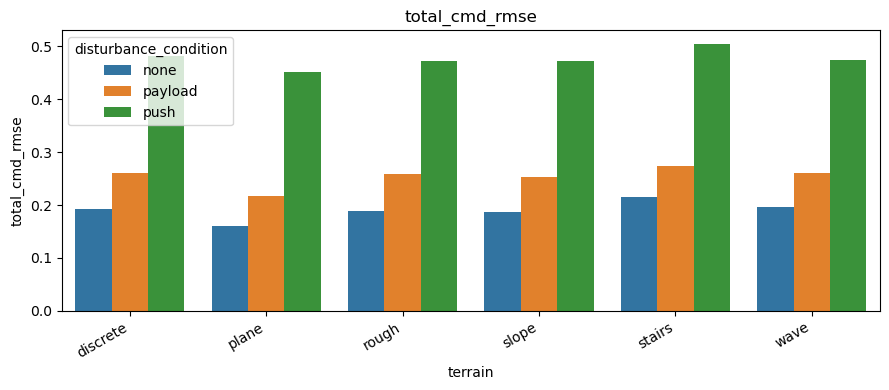

In [12]:
def plot_metric_by_terrain(results, metric, include_all=False):
    plot_df = results.copy()
    if not include_all:
        plot_df = plot_df[plot_df["terrain"] != "ALL"]

    if metric not in plot_df.columns:
        raise KeyError(f"{metric} not found in results.")

    plt.figure(figsize=(9, 4))
    if sns is not None:
        sns.barplot(data=plot_df, x="terrain", y=metric, hue="disturbance_condition")
    else:
        for condition, group in plot_df.groupby("disturbance_condition"):
            plt.bar(group["terrain"], group[metric], label=condition)
        plt.legend()

    plt.title(metric)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


plot_metric_by_terrain(combined_results, "total_cmd_rmse")


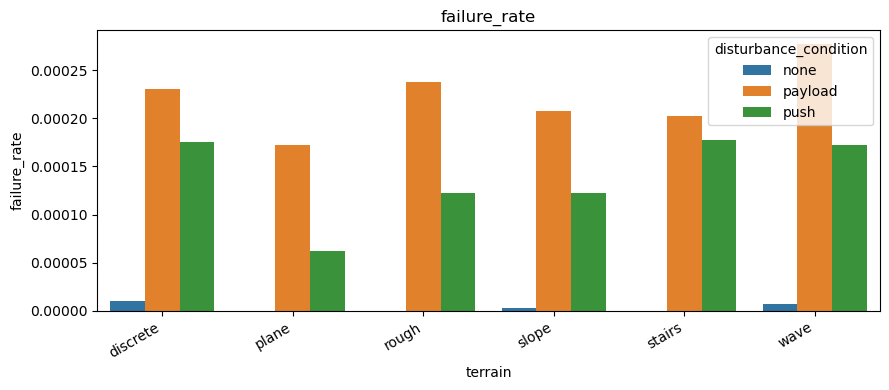

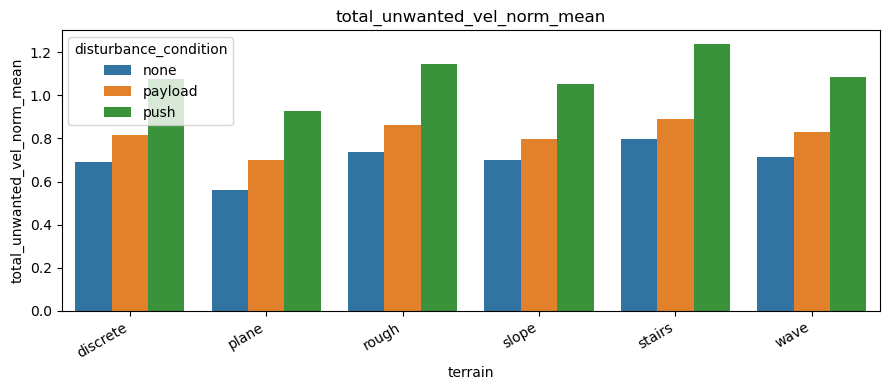

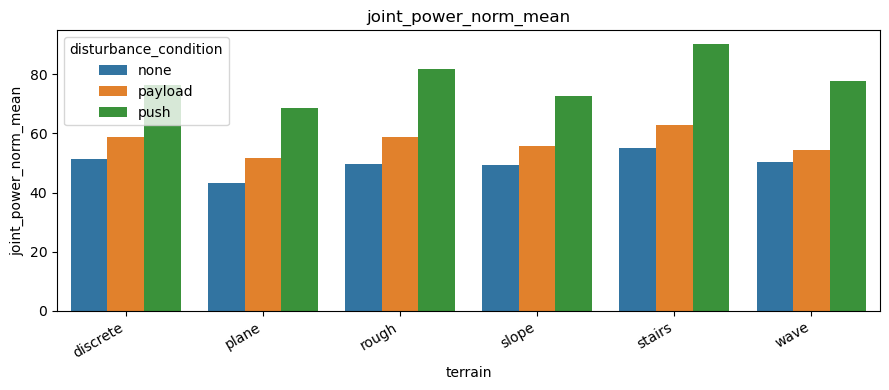

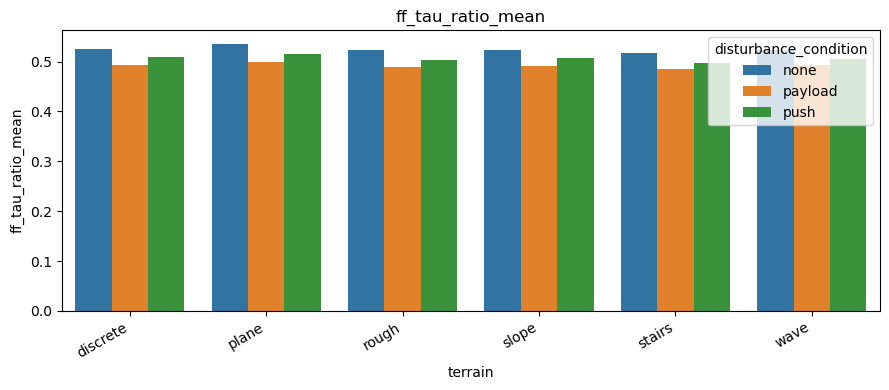

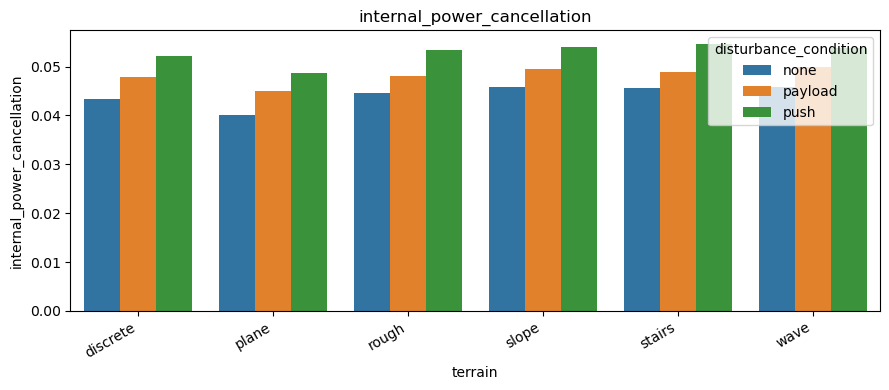

In [13]:
# Example additional plots
for metric in [
    "failure_rate",
    "total_unwanted_vel_norm_mean",
    "joint_power_norm_mean",
    "ff_tau_ratio_mean",
    "internal_power_cancellation",
]:
    if metric in combined_results.columns:
        plot_metric_by_terrain(combined_results, metric)


## Optional: compare multiple approaches

If you want to compare several approaches under the same experiment folder, set `APPROACHES` below and run the cell. It reuses the same functions above.


In [14]:
APPROACHES = ["pact"]  # e.g., ["pact", "pos", "tau"]

all_approach_dfs = []
for approach in APPROACHES:
    ft = find_eval_files(
        EXP_FOLDER,
        approach,
        disturbance_condition=DISTURBANCE_CONDITION,
    )
    if len(ft) == 0:
        print(f"No files found for approach: {approach}")
        continue

    all_approach_dfs.append(load_eval_dataset(ft))

if all_approach_dfs:
    df_multi = pd.concat(all_approach_dfs, ignore_index=True)

    multi_per_terrain = summarize_by_terrain(df_multi)
    multi_all_terrain = summarize_all_terrains(df_multi)
    multi_results = pd.concat([multi_per_terrain, multi_all_terrain], ignore_index=True)

    display(multi_results[[c for c in available_summary_cols if c in multi_results.columns]].round(4))
else:
    print("No approach files loaded.")


No files found for approach: pact
No approach files loaded.


In [15]:
def plot_metric_by_approach_and_terrain(results, metric, terrain_filter=None):
    plot_df = results.copy()

    if terrain_filter is not None:
        plot_df = plot_df[plot_df["terrain"].isin(terrain_filter)]

    if metric not in plot_df.columns:
        raise KeyError(f"{metric} not found in results.")

    plt.figure(figsize=(10, 4))
    if sns is not None:
        sns.barplot(data=plot_df, x="terrain", y=metric, hue="approach")
    else:
        for approach, group in plot_df.groupby("approach"):
            plt.bar(group["terrain"], group[metric], label=approach)
        plt.legend()

    plt.title(metric)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


if "multi_results" in globals():
    plot_metric_by_approach_and_terrain(multi_results, "total_cmd_rmse")
